In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (roc_auc_score, classification_report, 
                             RocCurveDisplay, confusion_matrix)
from sklearn.preprocessing import LabelEncoder
import shap
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv("../data/processed/trials_clean.csv")

# Same cleaning as previous notebooks
p99 = df["enrollment_actual"].quantile(0.99)
df_clean = df[df["enrollment_actual"] <= p99].copy()

print(f"Dataset: {len(df_clean):,} trials")
print(df_clean[["phase","sponsor_class","allocation","is_oncology","has_nudge"]].describe())

Dataset: 18,457 trials
        is_oncology     has_nudge
count  18457.000000  18457.000000
mean       0.128244      0.025356
std        0.334370      0.157209
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        0.000000      0.000000
max        1.000000      1.000000


## Notebook 4 — Predictive Modeling

The previous notebooks established that nudge trials enroll significantly more 
participants. But what *other* trial characteristics predict enrollment success?

**Research question:** Can we predict whether a clinical trial will meet an 
ambitious enrollment target (≥100 participants) using only trial design features 
available at the time of registration?

**Outcome:** Binary — did the trial enroll ≥100 participants? (33% of trials)

**Features:**
- `has_nudge` — behavioral nudge intervention
- `is_oncology` — oncology vs other condition
- `phase` — trial phase (1, 2, 3, 4, NA)
- `sponsor_class` — INDUSTRY, NIH, FED, OTHER, etc.
- `allocation` — RANDOMIZED vs NON_RANDOMIZED

**Models compared:**
- Logistic Regression (baseline, interpretable)
- Random Forest (handles non-linearity, interactions)
- Gradient Boosting (best performance, SHAP-explainable)

**Key output:** SHAP feature importance — which features drive predictions, 
and does `has_nudge` appear as a meaningful predictor after controlling for 
other trial characteristics?

In [5]:
from sklearn.preprocessing import OneHotEncoder

# Target
THRESHOLD = 100
df_model = df_clean.copy()
df_model["success"] = (df_model["enrollment_actual"] >= THRESHOLD).astype(int)

print(f"Target distribution (≥{THRESHOLD} participants):")
print(df_model["success"].value_counts())
print(f"  Success rate: {df_model['success'].mean():.1%}")

# Fill missing
df_model["phase"]         = df_model["phase"].fillna("N/A")
df_model["sponsor_class"] = df_model["sponsor_class"].fillna("UNKNOWN")
df_model["allocation"]    = df_model["allocation"].fillna("N/A")

# One-hot encode categoricals
cat_features = ["phase", "sponsor_class", "allocation"]
num_features = ["has_nudge", "is_oncology"]

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = ohe.fit_transform(df_model[cat_features])
X_num = df_model[num_features].values
X     = np.hstack([X_num, X_cat])
y     = df_model["success"].values

# Feature names for SHAP
ohe_feature_names = ohe.get_feature_names_out(cat_features).tolist()
feature_names = ["Has Nudge", "Is Oncology"] + ohe_feature_names

print(f"\nFeature matrix: {X.shape}")
print(f"  Numeric features : {num_features}")
print(f"  OHE features     : {len(ohe_feature_names)} columns from {cat_features}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Train success rate: {y_train.mean():.1%}")
print(f"Test success rate : {y_test.mean():.1%}")

Target distribution (≥100 participants):
success
0    12211
1     6246
Name: count, dtype: int64
  Success rate: 33.8%

Feature matrix: (18457, 21)
  Numeric features : ['has_nudge', 'is_oncology']
  OHE features     : 19 columns from ['phase', 'sponsor_class', 'allocation']

Train: 13,842 | Test: 4,615
Train success rate: 33.8%
Test success rate : 33.8%


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

models_to_train = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting"  : GradientBoostingClassifier(n_estimators=200, random_state=42),
}

print("Cross-validation ROC-AUC (5-fold) — all models use OneHotEncoding:")
print("-" * 60)
for name, model in models_to_train.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    model.fit(X_train, y_train)
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    results[name] = {
        "model"    : model,
        "cv_mean"  : cv_scores.mean(),
        "cv_std"   : cv_scores.std(),
        "test_auc" : test_auc,
    }
    print(f"{name:25s} CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f} | Test AUC: {test_auc:.3f}")

Cross-validation ROC-AUC (5-fold) — all models use OneHotEncoding:
------------------------------------------------------------
Logistic Regression       CV AUC: 0.734 ± 0.006 | Test AUC: 0.730
Random Forest             CV AUC: 0.734 ± 0.004 | Test AUC: 0.733
Gradient Boosting         CV AUC: 0.738 ± 0.005 | Test AUC: 0.734


**Note on encoding:** All models use OneHotEncoding for categorical features 
(phase, sponsor class, allocation). This is the correct choice for all model 
types — LabelEncoding assigns arbitrary numeric order to categories 
(INDUSTRY=0, NIH=1, FED=2) which is meaningless and penalizes linear models. 
With correct encoding, Logistic Regression AUC improved from 0.677 to 0.730, 
closing most of the gap with tree-based models and confirming the relationship 
between trial design features and enrollment success is largely linear.

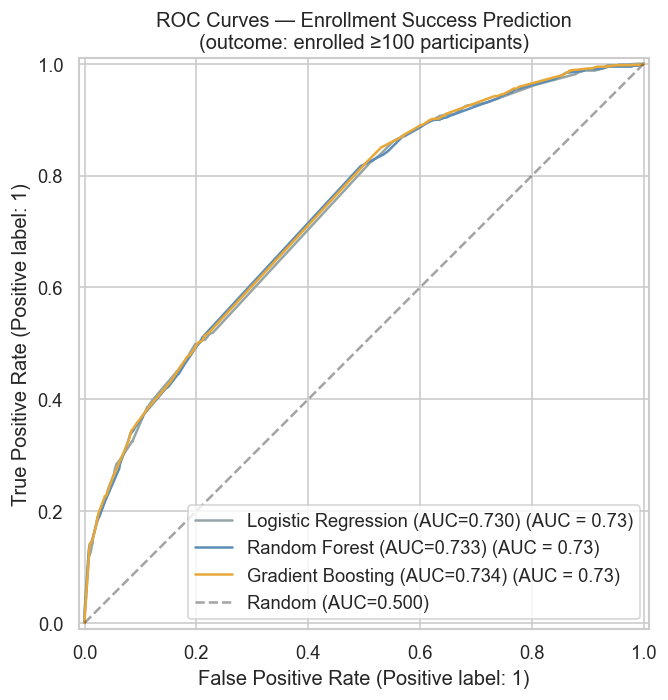

Saved ✓


In [7]:
fig, ax = plt.subplots(figsize=(7, 6))

colors = ["#95a5a6", "#5B8DB8", "#E8A838"]
for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_estimator(
        res["model"], X_test, y_test,
        name=f"{name} (AUC={res['test_auc']:.3f})",
        ax=ax, color=color
    )

ax.plot([0,1],[0,1], "k--", alpha=0.4, label="Random (AUC=0.500)")
ax.set_title("ROC Curves — Enrollment Success Prediction\n(outcome: enrolled ≥100 participants)")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("../figures/06_roc_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved ✓")

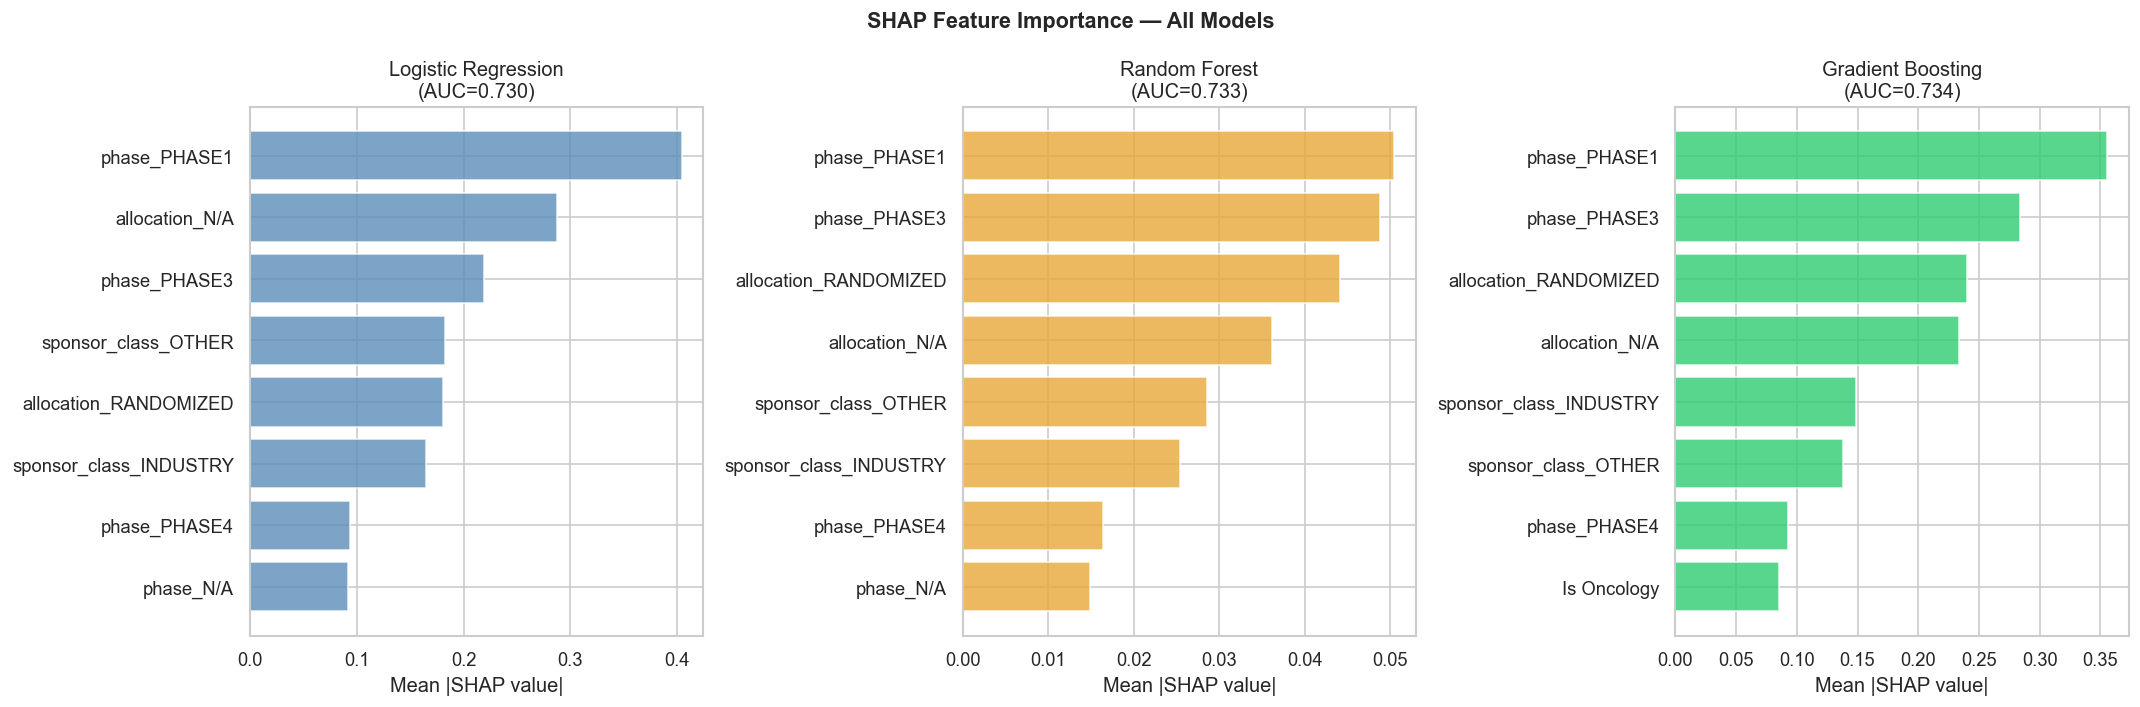

Saved ✓


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("SHAP Feature Importance — All Models", 
             fontsize=13, fontweight="bold")

feature_names_arr = np.array(feature_names)

for ax, (name, res) in zip(axes, results.items()):
    model = res["model"]
    
    if name == "Logistic Regression":
        explainer = shap.LinearExplainer(model, X_train)
        shap_vals = explainer.shap_values(X_test)
    else:
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_test)
        # Tree models return list [class0, class1] or 3D array — take class 1
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
        elif shap_vals.ndim == 3:
            shap_vals = shap_vals[:, :, 1]

    # Top 8 features by mean |SHAP|
    mean_shap = np.abs(shap_vals).mean(axis=0)
    top_idx   = np.argsort(mean_shap)[-8:]

    color = "#5B8DB8" if name == "Logistic Regression" else \
            "#E8A838" if name == "Random Forest" else "#2ecc71"

    ax.barh(
        feature_names_arr[top_idx].tolist(),
        mean_shap[top_idx],
        color=color,
        alpha=0.8
    )
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(f"{name}\n(AUC={res['test_auc']:.3f})")

plt.tight_layout()
plt.savefig("../figures/07_shap_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved ✓")

In [13]:
# Where does Has Nudge rank across all models?
print("Rank of 'Has Nudge' feature across models:")
print("-" * 45)

for name, res in results.items():
    model = res["model"]
    if name == "Logistic Regression":
        explainer = shap.LinearExplainer(model, X_train)
        shap_vals = explainer.shap_values(X_test)
    else:
        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_test)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
        elif shap_vals.ndim == 3:
            shap_vals = shap_vals[:, :, 1]

    mean_shap  = np.abs(shap_vals).mean(axis=0)
    ranked_idx = np.argsort(mean_shap)[::-1]
    nudge_rank = np.where(ranked_idx == 0)[0][0] + 1  # index 0 = Has Nudge
    nudge_shap = mean_shap[0]
    total_feat = len(mean_shap)

    print(f"{name:25s} rank: {nudge_rank}/{total_feat} | mean |SHAP|: {nudge_shap:.4f}")

Rank of 'Has Nudge' feature across models:
---------------------------------------------
Logistic Regression       rank: 11/21 | mean |SHAP|: 0.0434
Random Forest             rank: 10/21 | mean |SHAP|: 0.0107
Gradient Boosting         rank: 10/21 | mean |SHAP|: 0.0487


## SHAP Analysis — A Seeming Contradiction

The frequentist and Bayesian tests (Notebooks 2 and 3) showed nudge trials 
enroll **2x more participants** with p<10⁻²⁶. Yet SHAP ranks `Has Nudge` 
**10th out of 21 features**. How do we reconcile this?

**The answer: confounding by design.**

The A/B tests compared nudge vs control trials directly — and found a massive 
difference. But that difference is largely *explained* by other features:

- Nudge trials are disproportionately **Phase 3** (larger by design)
- Nudge trials are more likely **RANDOMIZED** (more rigorous, better funded)
- Nudge trials skew toward **OTHER sponsors** (academic medical centers with 
  outreach infrastructure)

Once the predictive model controls for phase, allocation, and sponsor — the 
*residual* contribution of `has_nudge` drops to rank 10/21.

**This is not a contradiction — it's a deeper finding:**

| Analysis | What it measures |
|---|---|
| A/B test (Notebooks 2-3) | Total association between nudge and enrollment |
| SHAP (Notebook 4) | Unique contribution of nudge *after controlling for confounders* |

The raw 2x enrollment advantage of nudge trials is real, but it reflects 
**trial design characteristics** more than the nudge intervention itself. 
Trials designed with outreach programs are also larger, better funded, 
and more rigorously structured from the start.

> This is a classic observational data challenge — and exactly why 
> randomized experiments exist. A true RCT randomly assigning nudge vs 
> no-nudge to otherwise identical trials would isolate the causal effect.

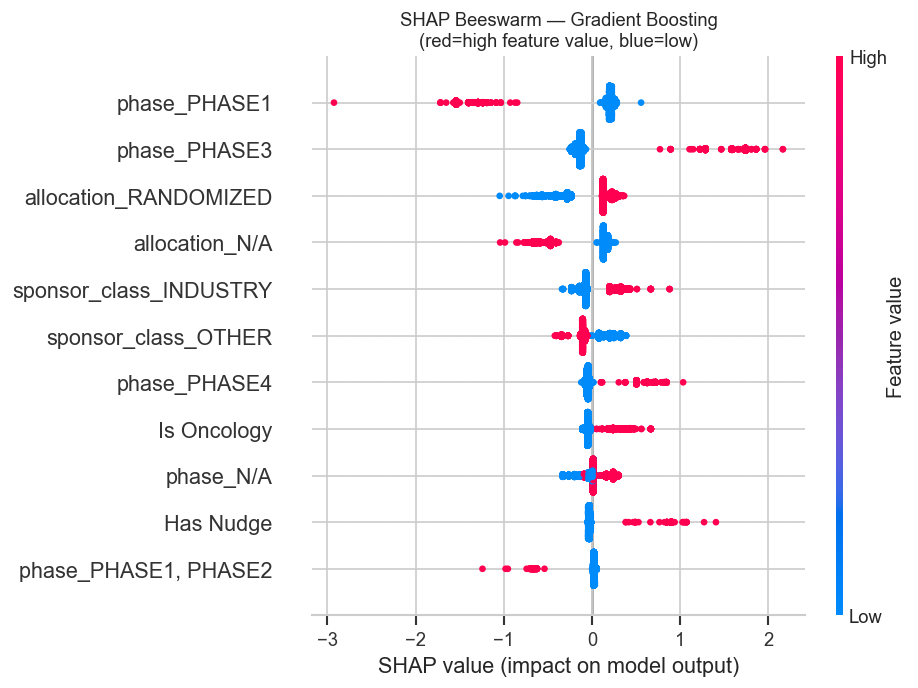

Saved ✓


In [14]:
# Beeswarm for GBM — top 12 features including Has Nudge
gbm = results["Gradient Boosting"]["model"]
explainer = shap.TreeExplainer(gbm)
shap_vals = explainer.shap_values(X_test)
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]
elif shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 1]

mean_shap  = np.abs(shap_vals).mean(axis=0)

# Force Has Nudge (idx 0) into top features
top_idx = np.argsort(mean_shap)[-11:].tolist()
if 0 not in top_idx:
    top_idx = [0] + np.argsort(mean_shap)[-10:].tolist()
top_idx = sorted(top_idx)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals[:, top_idx],
    X_test[:, top_idx],
    feature_names=feature_names_arr[top_idx].tolist(),
    show=False,
    plot_type="dot"
)
plt.title("SHAP Beeswarm — Gradient Boosting\n(red=high feature value, blue=low)", 
          fontsize=11)
plt.tight_layout()
plt.savefig("../figures/08_shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved ✓")